# Phân đoạn Khách hàng (Customer Segmentation) qua Phân cụm

## 🎯 Mục tiêu Nghiệp vụ
Trong bối cảnh ngân hàng, việc biết khách hàng nào sắp rời bỏ là chưa đủ. Chúng ta cần hiểu **hành vi tài chính** của họ để đưa ra các gói sản phẩm phù hợp. Phân cụm giúp ta chia khách hàng thành các nhóm có đặc điểm tương đồng (như thói quen quẹt thẻ, hạn mức tín dụng, nợ xoay vòng).

## 🛠️ Lựa chọn Thuộc tính (Feature Selection)
Chúng ta chọn 5 biến hành vi tài chính cốt lõi (Finance Behavioral Features) để phân nhóm:
1. **Credit_Limit**: Phân cấp khả năng tài chính.
2. **Total_Revolving_Bal**: Đo lường lợi nhuận từ lãi vay nợ xoay vòng.
3. **Avg_Utilization_Ratio**: Thói quen sử dụng thẻ hàng tháng.
4. **Total_Trans_Ct**: Mức độ tương tác/gắn kết với ngân hàng.
5. **Total_Ct_Chng_Q4_Q1**: Dấu hiệu thay đổi thói quen (tăng/giảm chi tiêu).

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import Birch, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
try:
    from sklearn_extra.cluster import KMedoids
except:
    print("Lưu ý: Chưa cài sklearn-extra cho PAM")

import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/BankChurners_cleaned.csv')
features = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Sẵn sàng phân cụm trên dữ liệu 5 biến và {len(df)} dòng.")

Sẵn sàng phân cụm trên dữ liệu 5 biến và 10127 dòng.


## 🔍 Tìm tham số K tối ưu (Model Selection)

Sử dụng **Silhouette Score** để đánh giá chất lượng cụm. Điểm Silhouette càng cao (gần 1) nghĩa là các cụm càng tách biệt và chặt chẽ.

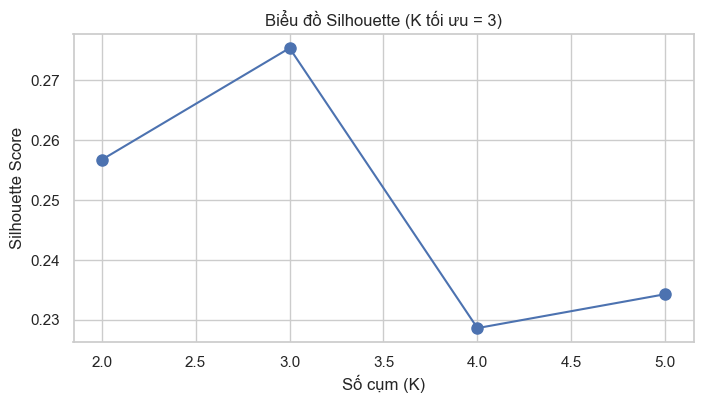

In [7]:
sil_scores = []
K_range = range(2, 6)
for k in K_range:
    # Dùng PAM làm chuẩn để tìm K
    model = KMedoids(n_clusters=k, random_state=42, method='pam')
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = K_range[np.argmax(sil_scores)]
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-', marker='o', markersize=8)
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title(f'Biểu đồ Silhouette (K tối ưu = {best_k})')
plt.show()

## 📊 So sánh các thuật toán Phân cụm

Trong phần này, chúng ta sẽ thực hiện so sánh chi tiết giữa thuật toán PAM (K-Medoids) và BIRCH dựa trên các chỉ số hiệu năng và chất lượng cụm:

--- So sánh hiệu năng (K=3) ---



,Thuật toán,Thời gian (s),Silhouette (↑),DB Index (↓),CH Index (↑)
0,PAM (K-Medoids),59.2212,0.2754,1.4520,3324.3368
1,BIRCH,0.3621,0.1993,1.5141,1301.7251


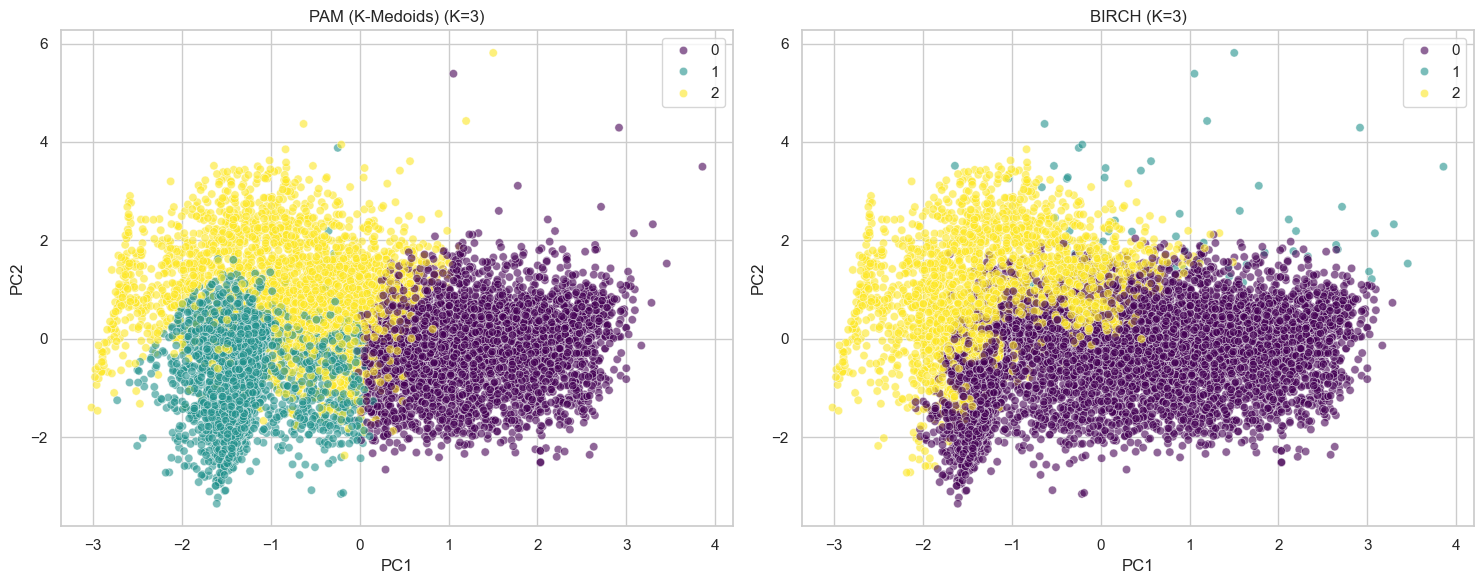

In [ ]:


# --- Tìm eps tối ưu cho DBSCAN bằng K-distance graph ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

# Tự động tìm eps tại điểm "khuỷu tay" (elbow point)
diff = np.diff(distances)
elbow_idx = np.argmax(diff) + 1
eps_optimal = round(distances[elbow_idx], 2)
print(f"Eps tự động tìm được: {eps_optimal}")

results = []
algorithms = {
    'PAM (K-Medoids)': KMedoids(n_clusters=best_k, random_state=42, method='pam'),
    'BIRCH': Birch(n_clusters=best_k),
    'DBSCAN': DBSCAN(eps=eps_optimal, min_samples=5)
}

print(f"--- So sánh hiệu năng (K={best_k}) ---\n")

for name, model in algorithms.items():
    # 1. Đo thời gian chạy
    start_time = time.time()
    labels = model.fit_predict(X_scaled)
    exec_time = time.time() - start_time

    # 2. Lọc nhiễu cho DBSCAN (label == -1 là noise)
    mask = labels != -1
    n_clusters_found = len(set(labels[mask]))
    n_noise = np.sum(labels == -1)

    # 3. Tính toán các chỉ số (cần ít nhất 2 cụm và có điểm không phải noise)
    if n_clusters_found >= 2 and mask.sum() > 0:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        db  = davies_bouldin_score(X_scaled[mask], labels[mask])
        ch  = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        sil = db = ch = float('nan')

    results.append({
        'Thuật toán':      name,
        'Số cụm':          n_clusters_found if name == 'DBSCAN' else best_k,
        'Noise points':    n_noise if name == 'DBSCAN' else 0,
        'Thời gian (s)':   round(exec_time, 4),
        'Silhouette (↑)':  round(sil, 4) if not np.isnan(sil) else 'N/A',
        'DB Index (↓)':    round(db,  4) if not np.isnan(db)  else 'N/A',
        'CH Index (↑)':    round(ch,  4) if not np.isnan(ch)  else 'N/A'
    })

# Hiển thị kết quả dưới dạng bảng
df_results = pd.DataFrame(results)
display(df_results)

# --- Trực quan hóa kết quả so sánh trên PCA ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, (name, model) in enumerate(algorithms.items()):
    labels = model.labels_ if hasattr(model, 'labels_') else model.predict(X_scaled)

    # Với DBSCAN: tô màu riêng cho noise (-1)
    palette = 'viridis'
    if name == 'DBSCAN':
        unique_labels = sorted(set(labels))
        palette = {lbl: ('black' if lbl == -1 else sns.color_palette('viridis', len(unique_labels))[j])
                   for j, lbl in enumerate(unique_labels)}

    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=labels, palette=palette,
        ax=axes[i], legend='full', alpha=0.6
    )

    n_noise = np.sum(labels == -1)
    title = f"{name} (K={best_k})" if name != 'DBSCAN' \
        else f"DBSCAN (eps={eps_optimal}, noise={n_noise})"
    axes[i].set_title(title)
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 📑 Biện luận Nghiệp vụ (Business Interpretation)

Nhóm sẽ phân tích ý nghĩa sâu sắc của từng cụm dựa trên bộ dữ liệu PAM (thường cho kết quả ổn định nhất).

BẢNG ĐẶC TRƯNG TỪNG NHÓM KHÁCH HÀNG:


,Credit_Limit,Total_Revolving_Bal,Avg_Utilization_Ratio,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Size
PAM_Cluster,,,,,,
0,3229.952537,1658.478937,0.563006,64.697942,0.739772,4178
1,5560.925627,131.699382,0.031695,58.929117,0.659907,2751
2,18331.127892,1402.247655,0.107698,70.169481,0.721233,3198


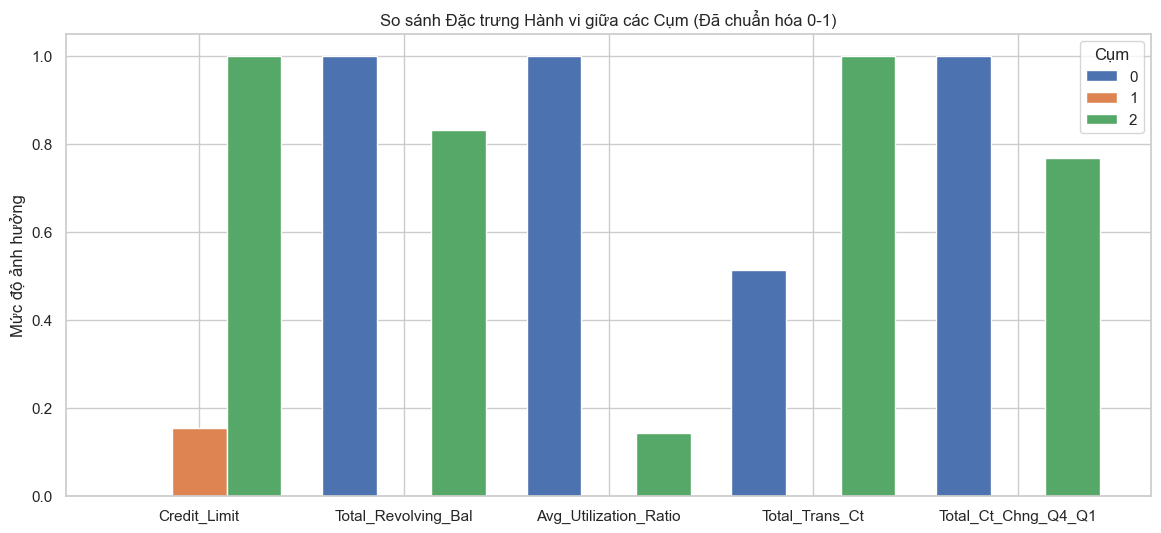

In [9]:
best_model_name = 'PAM (K-Medoids)'
pam_final = KMedoids(n_clusters=best_k, random_state=42, method='pam').fit(X_scaled)
df['PAM_Cluster'] = pam_final.labels_

# Tạo bảng tóm tắt trung bình
summary = df.groupby('PAM_Cluster')[features].mean()
summary['Size'] = df.groupby('PAM_Cluster').size()

print("BẢNG ĐẶC TRƯNG TỪNG NHÓM KHÁCH HÀNG:")
display(summary.style.background_gradient(cmap='YlGn'))

# Vẽ biểu đồ đũa (So sánh đặc trưng giữa các cụm)
summary_scaled = (summary - summary.min()) / (summary.max() - summary.min())
summary_scaled.drop(columns='Size').T.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('So sánh Đặc trưng Hành vi giữa các Cụm (Đã chuẩn hóa 0-1)')
plt.ylabel('Mức độ ảnh hưởng')
plt.xticks(rotation=0)
plt.legend(title='Cụm')
plt.show()

## 🏆 Kết luận & Đề xuất hành động cho Ngân hàng

Dựa trên bảng số liệu trên, ta có thể định danh các nhóm như sau (Ví dụ):

### 1. NHÓM KHÁCH HÀNG "CHURN RISK" (Nguy cơ rời bỏ)
- **Đặc điểm:** `Total_Trans_Ct` thấp, `Total_Ct_Chng_Q4_Q1` giảm mạnh.
- **Giải pháp:** Ngân hàng cần gọi điện chăm sóc, tặng Voucher hoặc giảm phí thường niên để giữ chân.

### 2. NHÓM KHÁCH HÀNG "CREDIT HUNTER" (Dùng thẻ vì hạn mức)
- **Đặc điểm:** `Credit_Limit` rất cao nhưng `Avg_Utilization_Ratio` lại thấp (ít quẹt thẻ).
- **Giải pháp:** Gửi các chương trình Cashback lớn cho mỗi giao dịch để kích cầu chi tiêu.

### 3. NHÓM KHÁCH HÀNG "PROFITABLE REVOLVERS" (Khách hàng mang lại lãi suất)
- **Đặc điểm:** `Total_Revolving_Bal` cao (để nợ xoay vòng nhiều).
- **Giải pháp:** Cung cấp các gói trả góp lãi suất thấp để duy trì dòng lợi nhuận ổn định.

---